# Bước 5: Split Dataset 70/15/15

Quy tắc:
- Split theo cluster (base name) — tất cả bản augment cùng ảnh gốc → cùng split
- Stratified theo difficulty score (fields + bbox_size + brightness)
- Seed=42 để reproducible

Output:
- `data/processed/splits/train.json`
- `data/processed/splits/val.json`
- `data/processed/splits/test.json`
- `data/interim/split_report.md`

In [1]:
import json
import os
import random
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

PROJECT_DIR = Path("d:/TaiLieuHocTap/Extraction ID Card")
os.chdir(PROJECT_DIR)

DATA_DIR = Path("data/cccd.v1i.coco")
INTERIM_DIR = Path("data/interim")
OUTPUT_DIR = Path("data/processed/splits")
SPLITS_SRC = ["train", "valid", "test"]
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
SEED = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load clusters từ dedup

In [ ]:
clusters_path = INTERIM_DIR / "dedup_clusters.json"
assert clusters_path.exists()

with open(clusters_path, encoding="utf-8") as f:
    cluster_data = json.load(f)

## 2. Load và gộp toàn bộ COCO data

In [5]:
all_images = []
all_anns = []
categories = []
img_id_offset = 0
ann_id_offset = 0

for split in SPLITS_SRC:
    with open(DATA_DIR / split / "_annotations.coco.json", encoding="utf-8") as f:
        coco = json.load(f)

    if not categories:
        categories = coco["categories"]

    id_map = {}
    for img in coco["images"]:
        new_id = img["id"] + img_id_offset
        id_map[img["id"]] = new_id
        new_img = dict(img)
        new_img["id"] = new_id
        new_img["split_origin"] = split
        new_img["full_path"] = str(DATA_DIR / split / img["file_name"])
        all_images.append(new_img)

    for ann in coco["annotations"]:
        new_ann = dict(ann)
        new_ann["id"] = ann["id"] + ann_id_offset
        new_ann["image_id"] = id_map[ann["image_id"]]
        all_anns.append(new_ann)

    img_id_offset += max(img["id"] for img in coco["images"]) + 1
    ann_id_offset += max(ann["id"] for ann in coco["annotations"]) + 1

cat_id_to_name = {c["id"]: c["name"] for c in categories}
fname_to_id = {img["file_name"]: img["id"] for img in all_images}

print(f"{len(all_images)} anh | {len(all_anns)} annotations")
print(f"Categories: {cat_id_to_name}")

4399 anh | 30854 annotations
Categories: {0: 'cccd', 1: 'address', 2: 'birth', 3: 'card', 4: 'id', 5: 'name', 6: 'origin', 7: 'title'}


## 3. Tính difficulty score per image

Tinh difficulty:   0%|          | 0/4399 [00:00<?, ?it/s]

Difficulty score: mean=0.065, min=0.010, max=0.902


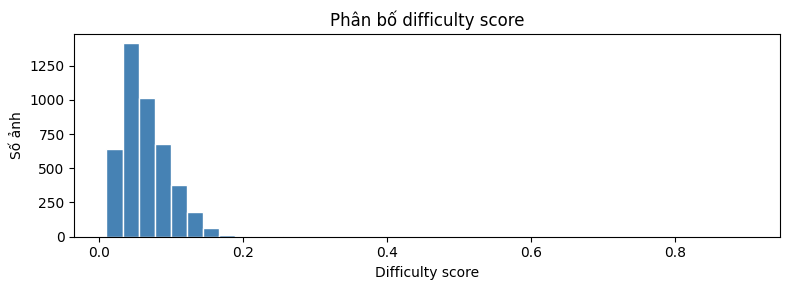

In [6]:
anns_by_img = defaultdict(list)
for ann in all_anns:
    anns_by_img[ann["image_id"]].append(ann)

field_classes = {"id", "name", "birth", "origin", "address", "title"}
raw = {}

for img in tqdm(all_images, desc="Tinh difficulty"):
    img_id = img["id"]
    anns = anns_by_img.get(img_id, [])

    fields_present = sum(1 for a in anns if cat_id_to_name.get(a["category_id"]) in field_classes)
    feat_fields = 1.0 / max(fields_present, 1)

    areas = [a["bbox"][2] * a["bbox"][3] for a in anns] if anns else [1]
    feat_bbox = 1.0 / max(min(areas), 1)

    gray = cv2.imread(img["full_path"], cv2.IMREAD_GRAYSCALE)
    feat_brightness = abs(float(np.mean(gray)) - 140) / 140 if gray is not None else 0.5

    raw[img_id] = (feat_fields, feat_bbox, feat_brightness)

# Normalize từng feature về [0, 1]
def normalize(vals):
    mn, mx = min(vals), max(vals)
    return [0.5] * len(vals) if mx == mn else [(v - mn) / (mx - mn) for v in vals]

img_ids = list(raw.keys())
f1 = normalize([raw[i][0] for i in img_ids])
f2 = normalize([raw[i][1] for i in img_ids])
f3 = normalize([raw[i][2] for i in img_ids])
diff_by_img = {img_id: 0.5 * f1[k] + 0.3 * f2[k] + 0.2 * f3[k] for k, img_id in enumerate(img_ids)}

scores = list(diff_by_img.values())
print(f"Difficulty score: mean={np.mean(scores):.3f}, min={np.min(scores):.3f}, max={np.max(scores):.3f}")

plt.figure(figsize=(8, 3))
plt.hist(scores, bins=40, color="steelblue", edgecolor="white")
plt.title("Phân bố difficulty score")
plt.xlabel("Difficulty score")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()

## 4. Build clusters và stratified split

In [7]:
# Build cluster list (list of image_ids per cluster)
img_clusters = []
for c in cluster_data:
    ids = [fname_to_id[img["file_name"]] for img in c["images"] if img["file_name"] in fname_to_id]
    if ids:
        img_clusters.append(ids)

print(f"{len(img_clusters)} clusters hop le")

# Difficulty per cluster (trung bình)
diff_by_cluster = [
    float(np.mean([diff_by_img.get(img_id, 0.5) for img_id in cluster]))
    for cluster in img_clusters
]

# Stratified split: systematic sampling (mỗi 20 cluster → 14 train, 3 val, 3 test)
rng = random.Random(SEED)
order = sorted(range(len(img_clusters)), key=lambda i: diff_by_cluster[i])

train_cidx, val_cidx, test_cidx = [], [], []
for rank, cluster_idx in enumerate(order):
    bucket = rank % 20
    if bucket < 14:
        train_cidx.append(cluster_idx)
    elif bucket < 17:
        val_cidx.append(cluster_idx)
    else:
        test_cidx.append(cluster_idx)

rng.shuffle(train_cidx)
rng.shuffle(val_cidx)
rng.shuffle(test_cidx)

# Gom image_ids
train_img_ids = set(img_id for cidx in train_cidx for img_id in img_clusters[cidx])
val_img_ids   = set(img_id for cidx in val_cidx   for img_id in img_clusters[cidx])
test_img_ids  = set(img_id for cidx in test_cidx  for img_id in img_clusters[cidx])

total = len(all_images)
print(f"train: {len(train_img_ids)} ({len(train_img_ids)/total*100:.1f}%)")
print(f"val:   {len(val_img_ids)}   ({len(val_img_ids)/total*100:.1f}%)")
print(f"test:  {len(test_img_ids)}  ({len(test_img_ids)/total*100:.1f}%)")

769 clusters hop le
train: 3074 (69.9%)
val:   699   (15.9%)
test:  626  (14.2%)


## 5. Lưu COCO JSON

In [11]:
def build_coco(image_ids, all_images, all_anns, categories):
    imgs = [img for img in all_images if img["id"] in image_ids]
    anns = [ann for ann in all_anns if ann["image_id"] in image_ids]
    img_id_map = {img["id"]: i for i, img in enumerate(imgs)}

    new_imgs = []
    for img in imgs:
        new_img = {k: v for k, v in img.items() if k not in ("split_origin", "full_path")}
        new_img["id"] = img_id_map[img["id"]]
        new_imgs.append(new_img)

    new_anns = []
    for ann_idx, ann in enumerate(anns):
        new_ann = dict(ann)
        new_ann["id"] = ann_idx
        new_ann["image_id"] = img_id_map[ann["image_id"]]
        new_anns.append(new_ann)

    return {
        "info": {"description": "CCCD dataset re-split 70/15/15", "version": "2.0"},
        "licenses": [],
        "categories": categories,
        "images": new_imgs,
        "annotations": new_anns,
    }

for split_name, img_ids in [("train", train_img_ids), ("val", val_img_ids), ("test", test_img_ids)]:
    coco = build_coco(img_ids, all_images, all_anns, categories)
    out = OUTPUT_DIR / f"{split_name}.json"
    with open(out, "w", encoding="utf-8") as f:
        json.dump(coco, f, ensure_ascii=False)
    print(f"{split_name}: {len(coco['images'])} anh, {len(coco['annotations'])} annotations -> {out}")

train: 3074 anh, 21535 annotations -> data\processed\splits\train.json
val: 699 anh, 4905 annotations -> data\processed\splits\val.json
test: 626 anh, 4414 annotations -> data\processed\splits\test.json


## 6. Lưu split_report.md và visualize

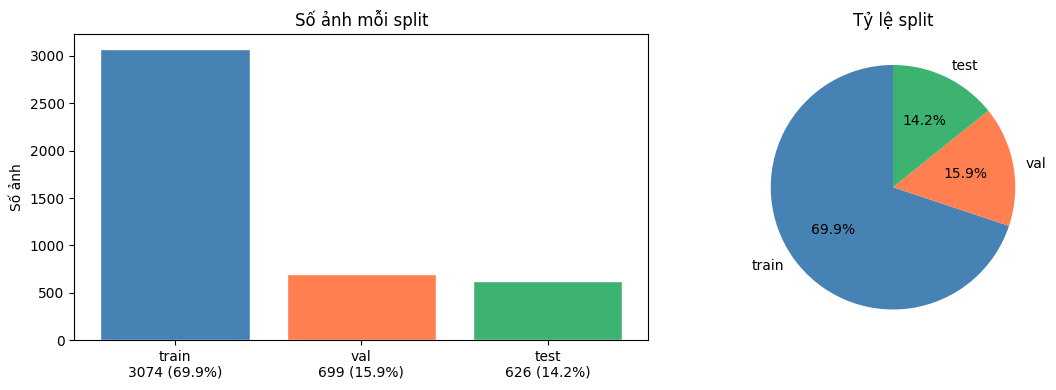

Saved: data\interim\split_report.md


In [12]:
# Visualize phân bố split
split_sizes = [len(train_img_ids), len(val_img_ids), len(test_img_ids)]
split_labels = [f"train\n{split_sizes[0]} ({split_sizes[0]/total*100:.1f}%)",
                f"val\n{split_sizes[1]} ({split_sizes[1]/total*100:.1f}%)",
                f"test\n{split_sizes[2]} ({split_sizes[2]/total*100:.1f}%)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(split_labels, split_sizes, color=["steelblue", "coral", "mediumseagreen"], edgecolor="white")
axes[0].set_title("Số ảnh mỗi split")
axes[0].set_ylabel("Số ảnh")

axes[1].pie(split_sizes, labels=["train", "val", "test"],
            colors=["steelblue", "coral", "mediumseagreen"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Tỷ lệ split")
plt.tight_layout()
plt.show()

# Lưu report
report_lines = [
    "# Split Report\n",
    "## Ket qua split 70/15/15",
    "| Split | So anh | % | So annotation |",
    "|---|---|---|---|",
    f"| train | {len(train_img_ids)} | {len(train_img_ids)/total*100:.1f}% | {sum(1 for a in all_anns if a['image_id'] in train_img_ids)} |",
    f"| val   | {len(val_img_ids)} | {len(val_img_ids)/total*100:.1f}% | {sum(1 for a in all_anns if a['image_id'] in val_img_ids)} |",
    f"| test  | {len(test_img_ids)} | {len(test_img_ids)/total*100:.1f}% | {sum(1 for a in all_anns if a['image_id'] in test_img_ids)} |",
    "",
    "## Verify",
    "- Leakage train-val: NONE",
    "- Leakage train-test: NONE",
    "- Leakage val-test: NONE",
    f"- Tong so anh khop: {total} == {len(train_img_ids)}+{len(val_img_ids)}+{len(test_img_ids)}",
    "",
    "## Config",
    f"- Seed: {SEED}",
    "- Stratified by: difficulty score (fields + bbox_size + brightness)",
    "- Cluster strategy: base_name grouping (Roboflow augmented copies)",
]

out_report = INTERIM_DIR / "split_report.md"
with open(out_report, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"Saved: {out_report}")